# EDA — Fraud Spike Detector

This notebook documents the reasoning behind decisions already made in `src/data_prep.py`. It isn't new analysis — it's a written record of what we found in the raw data and why we split it the way we did, so the next reader doesn't have to reverse-engineer it from the code.

## Load the raw data

First step before any decision-making: load the raw CSV and confirm its shape matches what the dataset card promises (284,807 transactions, 31 columns).

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")
print("shape:", df.shape)
df.head()

shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Null check

Checked before anything else because missing values would force an imputation decision that has to happen *before* the train/val/test split (to avoid leaking imputation statistics across splits). Confirmed there are none, so this dataset doesn't need that step.

In [2]:
df.isnull().sum().sum()

np.int64(0)

## Class balance — why 0.17% fraud is "extreme" imbalance

This number drives almost every downstream decision in this project: the metric we select models on (`03_tuning.ipynb`), the resampling strategy, and the split ratios below. A classifier that predicts "not fraud" for every single transaction would still score ~99.8% accuracy — which is why accuracy is useless here and gets ruled out early.

In [3]:
class_counts = df["Class"].value_counts()
fraud_rate = class_counts[1] / len(df)
print(class_counts)
print(f"\nfraud rate: {fraud_rate:.4%}")
print(f"trivial 'always predict non-fraud' accuracy: {1 - fraud_rate:.4%}")

Class
0    284315
1       492
Name: count, dtype: int64

fraud rate: 0.1727%
trivial 'always predict non-fraud' accuracy: 99.8273%


## Time / Amount distributions

`V1`–`V28` are already PCA components (see note below) and don't need inspection here — they arrive pre-scaled. `Time` and `Amount` are the only two columns on their original, raw scales, so they're the ones we need to understand before deciding how (and whether) to scale them in `src/features.py`.

In [4]:
df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


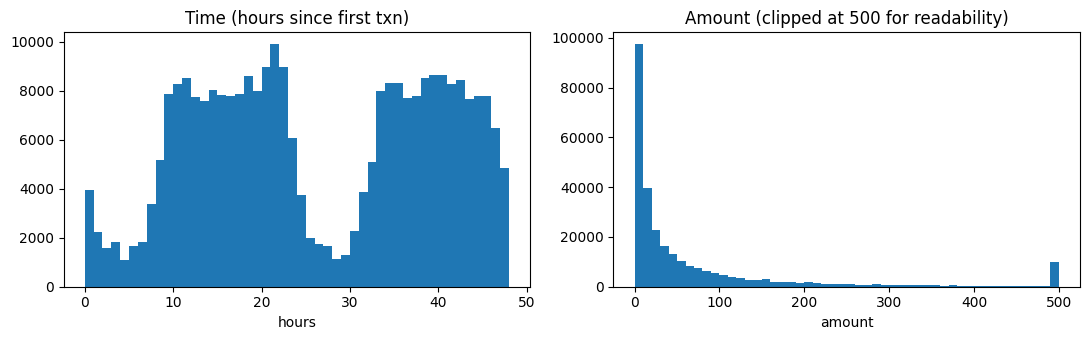

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df["Time"] / 3600, bins=48)
axes[0].set_title("Time (hours since first txn)")
axes[0].set_xlabel("hours")

axes[1].hist(df["Amount"].clip(upper=500), bins=50)
axes[1].set_title("Amount (clipped at 500 for readability)")
axes[1].set_xlabel("amount")
plt.tight_layout()
plt.show()

**Notes:**
- `Time` spans ~48 hours (172,792 seconds) and shows the expected daily dip-and-peak pattern of two overnight lulls — consistent with the dataset covering a 2-day window. It's a relative clock, not a timestamp, so it's useful as a cyclical/ordering signal but not as a calendar feature.
- `Amount` is heavily right-skewed (mean ~$88, but a max of ~$25,691) — most transactions are small, with a long tail of large ones. This is why it's a column that benefits from scaling before feeding it to models that are sensitive to feature magnitude (logistic regression), even though tree models don't strictly need it.

## V1–V28 are PCA-anonymized — what that means later

The dataset owner ran PCA on the original transaction features and released only the anonymized components, for confidentiality. We can confirm this from their summary statistics: mean ~0 and small, similar standard deviations across all 28 columns, which is the signature of already-standardized PCA output.

**Why this matters downstream:** it means `src/features.py` correctly leaves these columns untouched (only `Time`/`Amount` get scaled), and it means `src/explain.py`'s SHAP output can only ever say *which numbered component* drove a fraud score — never *what real-world transaction attribute* it corresponds to. That's a hard ceiling on explainability, not a gap we can close with better tooling.

In [6]:
v_cols = [f"V{i}" for i in range(1, 29)]
df[v_cols].describe().T[["mean", "std"]].round(3)

,mean,std
V1,0.0,1.959
V2,0.0,1.651
V3,-0.0,1.516
V4,0.0,1.416
V5,0.0,1.380
V6,0.0,1.332
V7,-0.0,1.237
V8,0.0,1.194
V9,-0.0,1.099
V10,0.0,1.089


## Split ratio — why 60/20/20 instead of 70/15/15

With only 492 fraud rows in the *entire* dataset, the split ratio isn't just about giving the model enough training data — it's about giving val and test enough **fraud examples** that PR-AUC, precision, and recall on those splits aren't noisy estimates from a handful of cases.

A 70/15/15 split would put roughly 15% × 492 ≈ 74 fraud rows in each of val and test — flipping just 3-4 of those from caught to missed swings recall by several percentage points, purely from small-sample noise. 60/20/20 pushes that to roughly 98-99 fraud rows in each split, meaningfully more stable, at an acceptable cost to training data (170k rows either way is far more than this model needs). This is why `src/data_prep.py` uses `test_size=0.4` then splits that remainder 50/50.

In [7]:
train = pd.read_csv("../data/processed/train.csv")
val = pd.read_csv("../data/processed/val.csv")
test = pd.read_csv("../data/processed/test.csv")

for name, part in [("train", train), ("val", val), ("test", test)]:
    n_fraud = int(part["Class"].sum())
    print(f"{name}: {len(part):>7,} rows, {n_fraud:>3} fraud ({n_fraud / len(part):.4%})")

train: 170,884 rows, 295 fraud (0.1726%)
val:  56,961 rows,  98 fraud (0.1720%)
test:  56,962 rows,  99 fraud (0.1738%)


The split is stratified on `Class`, so the ~0.17% fraud rate holds across all three splits — the counts above show that in practice. This split is created once (`src/data_prep.py`, fixed `random_state=42`) and the test set is never touched again until the single final evaluation in [`03_tuning.ipynb`](./03_tuning.ipynb).